In [1]:
%matplotlib inline

import math
import os
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import amjuel
import ehr
import xsection as xs

We use the H collisional radiative code *collrad* to model the fate of the products of H$_{2}^{+}$ dissociation:

$\frac{N_{n}}{n_{H_{2}^{+}}} = - (Q^{-1})_{nm} E_{H_{2}^+,m} - (Q^{-1})_{nm} \alpha_{m} \equiv R_{H}^{H_{2}^{+}}(p) + R_{2H}^{H_{2}^{+}}(p)$,

The first of the two terms on the right hand side represents the products of dissociative excitation.  The Janev, Langer, Evans and Post (JLEP) dissociative excitation process (2.2.13) provided only the production rate of $n=2$ atoms.  Reiter's 1992 PSI paper proposed an *ad hoc* procedure for estimating the $n=3$ production rate, which was used in DEGAS and then in the initial implementation of this process in DEGAS 2.  Reiter now instead uses Sawada's code which has a hardwired $1/n^{3}$ scaling for the higher states so that:

$E_{H_{2}^+,m} = [1, (2/3)^3, (2/4)^{3}, ... (2/m)^{3} ... ] < \sigma v>_{(2.2.13)}$.

The second term on the right hand side corresponds to dissociative recombination, (2.2.14).  In this case, JLEP does provide a scaling:

$\alpha_{m} = [0.1, 0.45, 0.22, 0.12, 0.069, ... (10/m^{3}) ... ] < \sigma v>_{(2.2.14)}$.

Using the notation from Kotov's thesis, we can then write out the expression for the **effective dissociative ionization rate for H$_{2}^{+}$**:

$S_{H_{2}^{+}} = S_{H_{2}^{+}}(X^{2}\Sigma_{g}^{+}) + \sum_{p > 1} S_{H}(p^{\prime}) R_{H}^{H_{2}^{+}}(p^{\prime})$,

where $S_{H_{2}^{+}}(X^{2}\Sigma_{g}^{+}) = < \sigma v>_{(2.2.11)}$ is the familiar dissociative ionization rate from JLEP.  The second term represents the ionization of dissociative excitation products.

We have incorporated these terms into *collrad*, and we can get $S_{H_{2}^{+}}$ from its *fort.19* file:

In [2]:
h2cr_19_saw = ehr.ehr_data('fort.19')
print(h2cr_19_saw.data_dict.keys())

dict_keys(['  H2 Dissociation Rate(jt,jn) (cm**3 s**-1)  Te(jt) = 10**(-1.2 + (jt-1)/10) jt=1,60\n', '  H2 Dissociative Ionization Rate(jt,jn) (cm**3 s**-1)\n', '  H2+ Dissociative Recombination Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociation Rate(jt,jn)  (cm**3 s**-1)\n', '  H2+ Dissociative Ionization Rate(jt,jn)  (cm**3 s**-1)\n', '  H2 Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=3 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=3 / n=1 (jt,jn)\n', '  H2 Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Excitation n=2 / n=1 (jt,jn)\n', '  H2+ Dissociative Recombination n=2 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=4 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=4 / n=1 (jt,jn)\n', ' H2 Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Excitation n=5 / n=1 (jt,jn)\n', ' H2+ Dissociative Recombination n=5 / n=1 (jt,jn)\n', ' H2 Dissociative Excit

In [3]:
S_H2p = h2cr_19_saw.get_one_var('H2+ Dissociative Ionization Rate')

We will be comparing with the reaction rate previously used by DEGAS 2 for this process, coming from the evaluation of the fit to JLEP reaction (2.2.11).   

In [4]:
data_dir = '../'
h2pdision_nc = xs.xs_netCDF.read_ncfile('h2pdision',data_dir)
h2pdision_nc.xs.list_vars()
print('  ')
h2pdision_nc.xs.print_var(0)
old_rate = h2pdision_nc.xs.get_var4plot(0)
print('  ')
h2pdision_nc.xs.print_var(2)
old_eloss = h2pdision_nc.xs.get_var4plot(2)

 j              Name                   Units     
 0 reaction_rate                  cm^3/s         
 1 dissociation_energy            eV             
 2 background_energy_loss_rate    eV*cm^3/s      
  
Dependent variable:  reaction_rate  Units:  cm^3/s 
 Multiplier:  1.00000e-06  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04
  
Dependent variable:  background_energy_loss_rate  Units:  eV*cm^3/s 
 Multiplier:  1.60218e-25  Spacing:  log 

  Indep. var.     Units    Multiplier  Spacing     Min.        Max.    
temperature     eV         1.60218e-19 log      1.00000e+00 5.01187e+04


We read in the corresponding rates from AMJUEL only for verification:

In [5]:
amj_file = 'amjuel.tex'

Use the same grid for the two sets of data.

In [6]:
ehr19Te = h2cr_19_saw.get_Te()
ehr19ne = h2cr_19_saw.get_ne()
num_Te = ehr19Te.shape[0]
num_ne = ehr19ne.shape[0]

In [7]:
H123 = 'H.4'
reacstr = '2.2.11'
fit_coef = amjuel.get_AMJUEL_fit(amj_file,H123,reacstr)
data_2211 = np.zeros((num_ne,num_Te))
for jt in range(num_Te):
    for jn in range(num_ne):
        data_2211[jn,jt] = amjuel.ne_Te_exp_fit(fit_coef,ehr19ne[jn],ehr19Te[jt])


Make a comparison plot.  

The designation "JCR" here and in the name of this and the other associated molecular dissociation reaction files stands for "Janev Collisional Radiative" since the original approach was to use the Janev rates for the dissociative excitation product distribution in *collrad*.

The previous DEGAS 2 rate for this process, without collisional radiative effects, is included for comparison.  Again, this is lower since it lacks contributions from the ionization of dissociative excitation products.  This process is sufficiently sensitive to those effects that they are apparent even at $10^{10}$ cm$^{-3}$; a previous plot performed with the AMJUEL rate at $10^{8}$ cm$^{-3}$ was much closer to the previous DEGAS 2 rate.

The different colors represent different densities, as is indicated by the legend.

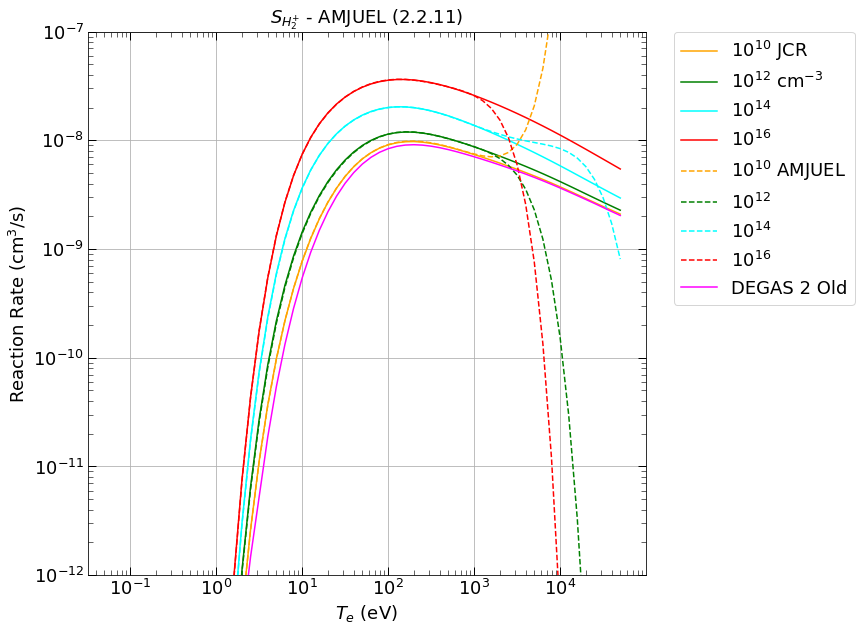

In [8]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,S_H2p[0,:],label='$10^{10}$ JCR',color='orange')
plt.plot(ehr19Te,S_H2p[4,:],label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,S_H2p[8,:],label='$10^{14}$ ',color='cyan')
plt.plot(ehr19Te,S_H2p[12,:],label='$10^{16}$',color='red')
plt.plot(ehr19Te,data_2211[0,:],label='$10^{10}$ AMJUEL',ls='--',color='orange')
plt.plot(ehr19Te,data_2211[4,:],label='$10^{12}$',ls='--',color='green')
plt.plot(ehr19Te,data_2211[8,:],label='$10^{14}$',ls='--',color='cyan')
plt.plot(ehr19Te,data_2211[12,:],label='$10^{16}$',ls='--',color='red')
plt.plot(old_rate[0],old_rate[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Reaction Rate (cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
plt.gca().set_ylim((1.e-12,1.e-7))
plt.gca().grid(axis='both',which='major')
plt.title('$S_{H_{2}^{+}}$ - AMJUEL (2.2.11)',fontsize=18)
plt.legend(bbox_to_anchor=(1.05,1),loc='upper left',borderaxespad=0,fontsize=18)

The prescriptions for the dissociation energy and electron loss rate per reaction are taken directly from JLEP.  Note, however, that Eirene uses 0.25 eV per product $H^{+}$ instead of 0.4 eV.

In [9]:
E_diss = 0.4
E_loss = 15.5
E_loss_rate = E_loss * S_H2p

Compare this loss rate with the one previously used by DEGAS 2 for this reaction:

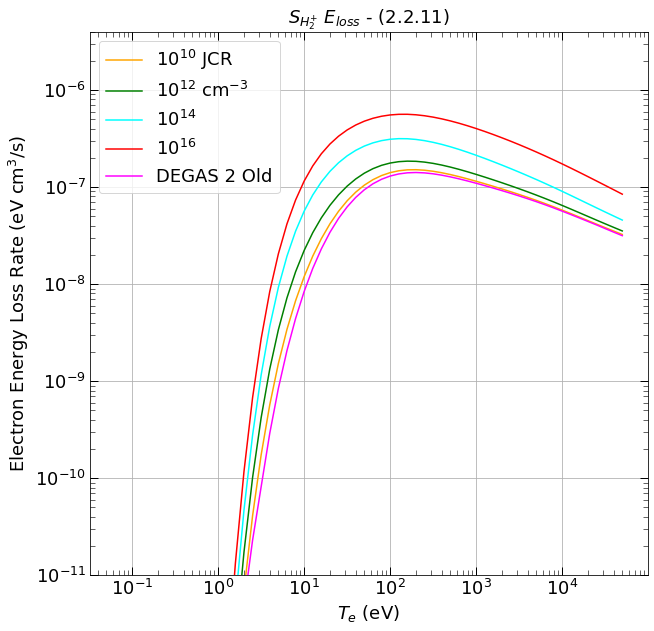

In [10]:
plt.figure(figsize=(10,10))
plt.plot(ehr19Te,E_loss_rate[0,:],
         label='$10^{10}$ JCR',color='orange')
plt.plot(ehr19Te,E_loss_rate[4,:],
         label='$10^{12}$ cm$^{-3}$',color='green')
plt.plot(ehr19Te,E_loss_rate[8,:],
         label='$10^{14}$',color='cyan')
plt.plot(ehr19Te,E_loss_rate[12,:],
         label='$10^{16}$',color='red')
plt.plot(old_eloss[0],old_eloss[1],label='DEGAS 2 Old',color='magenta')
plt.xlabel('$T_{e}$ (eV)',fontsize=18)
plt.ylabel('Electron Energy Loss Rate (eV cm$^{3}$/s)',fontsize=18)
plt.tick_params(which='major',labelsize=18,length=8,width=1,
                direction='in',top='on',right='on')
plt.tick_params(which='minor',length=5,
                direction='in',top='on',right='on')
plt.minorticks_on()
plt.gca().set_yscale('log')
plt.gca().set_xscale('log')
#plt.gca().set_xlim((1.,1.e3))
plt.gca().set_ylim((1.e-11,4.e-6))
plt.gca().grid(axis='both',which='major')
plt.title('$S_{H_{2}^{+}}$ $E_{loss}$ - (2.2.11)',fontsize=18)
plt.legend(fontsize=18)

Writing the data to the netCDF file consists of two steps.  The first involves defining the independent and dependent variables and then setting up the data table that holds all of the actual rate data.

The variables being written to this file are:  

0. Reaction rate(temperature,density)
1. Dissociation energy (scalar)
1. Background energy loss rate (temperature,density)

As above, there are num_ne density values and num_Te temperature values. Note that we change from using (density,temperature)  in these notebooks to (temperature,density) in the netCDF files.  The latter is to be consistent with the convention in the H CR files, such as hionize5.nc.  The swap is effected by sending the transpose of the data arrays in the set_data method calls below.

This initialization call sets the name of the reaction and the netCDF file, and specifies the number of dependent variables.

In [11]:
h2pdision = xs.xs_data('h2pdision_jcr',3)

Now, loop through the variables, providing the name, evaluation name (not really used), dimensions, units, multiplier, independent variable minimum and maximum, and the spacing method used for interpolation.

In [12]:
h2pdision.set_var(0,['reaction_rate','temperature','density'],'table',
              [num_Te,num_ne],['cm^3/s','eV','cm^-3'],
              [1.e-6,xs.electron_charge,1.e6],
              [ehr19Te[0],ehr19ne[0]],
              [ehr19Te[-1],ehr19ne[-1]],
              ['log']*3)

In [13]:
h2pdision.set_var(1,['dissociation_energy'],'table',
              [],['eV'],
              [xs.electron_charge],
              [],
              [],
              ['linear'])

In [14]:
h2pdision.set_var(2,['background_energy_loss_rate','temperature','density'],'table',
                  [num_Te,num_ne],['eV*cm^3/s','eV','cm^-3'],
                  [1.e-6*xs.electron_charge,xs.electron_charge,1.e6],
                  [ehr19Te[0],ehr19ne[0]],
                  [ehr19Te[-1],ehr19ne[-1]],
                  ['log']*3)

Fill in the data table:

In [15]:
h2pdision.set_data(0,S_H2p.T)
h2pdision.set_data(1,E_diss)
h2pdision.set_data(2,E_loss_rate.T)

Now open the netCDF file, write in the data using the h2pdision xs_data data structures, and close the file.

In [16]:
work_dir = './'
h2pdision_nc = xs.xs_netCDF.write_ncfile(h2pdision,work_dir,
                       'Reference atomic physics data for a reaction in degas 2',
                       'V. 1.0, effective H2+ dissociative ionization with CR effects')
h2pdision_nc.close()